<a href="https://colab.research.google.com/github/I-JAGADESH/DAA-LAB/blob/main/1A)_Practice_problem_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PROBLEM 1: Interpolation Search on Student Roll Numbers (1-10000)

Analysis of Search Performance:
--------------------------------------------------------------------------------
    Size    IS Probes      BS Comp    IS Time(ms)    BS Time(ms)  Improvement
--------------------------------------------------------------------------------
      10         1.40         3.00         0.0043         0.0019        53.3%
      50         2.60         4.60         0.0041         0.0015        43.5%
     100         2.40         6.20         0.0030         0.0015        61.3%
     200         2.20         7.20         0.0031         0.0020        69.4%
     500         2.40         8.20         0.0059         0.0029        70.7%
    1000         2.20         9.20         0.0049         0.0034        76.1%
    2500         1.80        11.20         0.0049         0.0034        83.9%
    5000         2.60        12.20         0.0062         0.0039        78.7%
    7500         2.17        12.33   

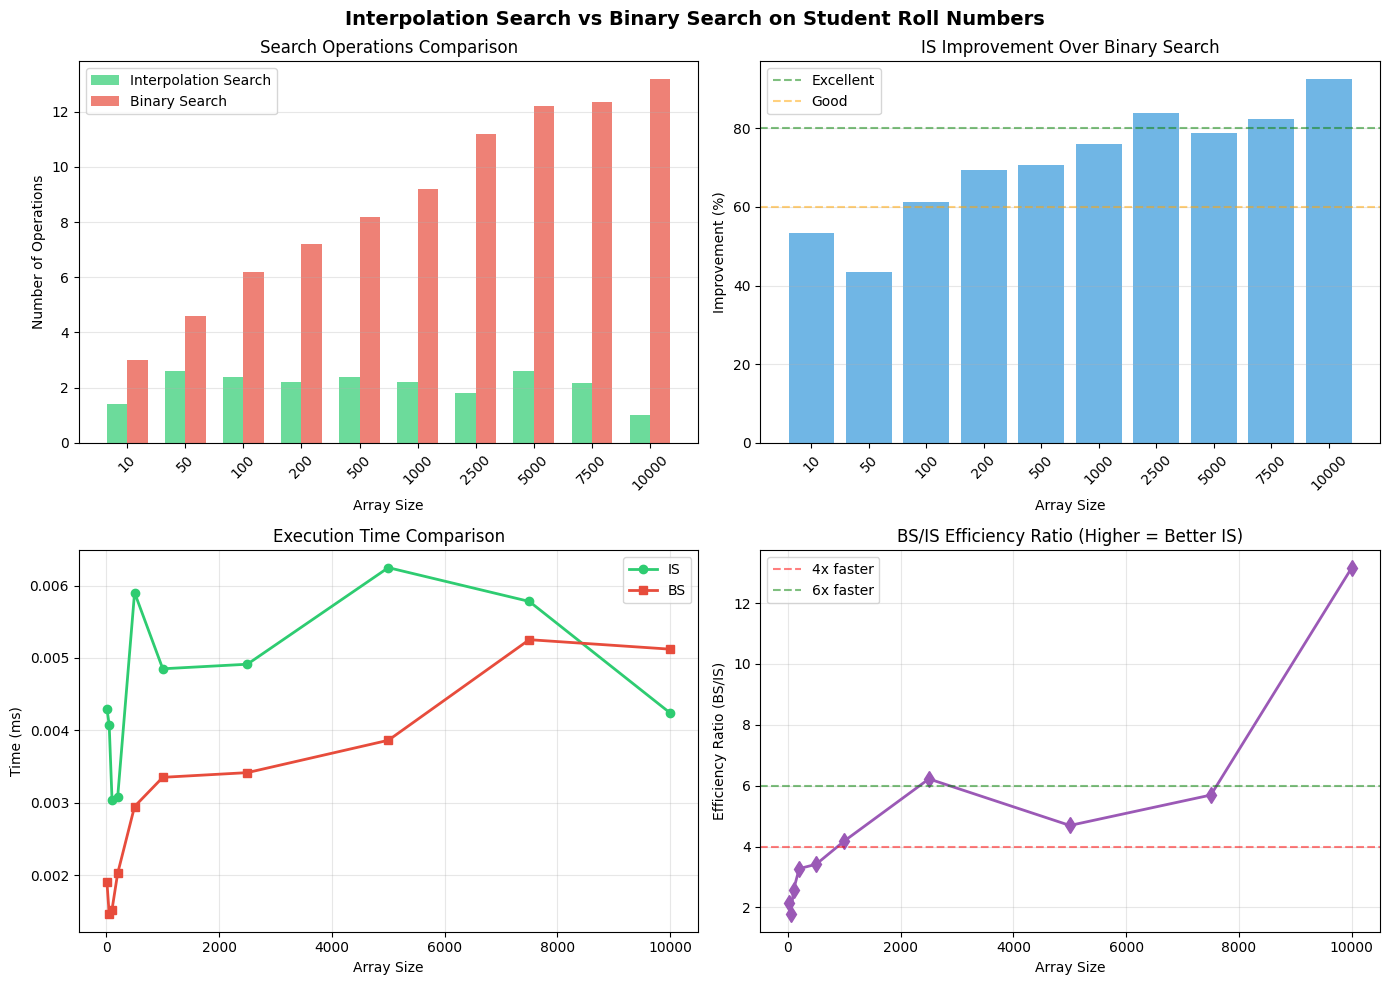

✓ Visualization created successfully!

KEY FINDINGS

1. Average probes/comparisons:
   • Interpolation Search: 2.08 probes
   • Binary Search:        8.73 comparisons

2. Average improvement: 71.2% fewer probes with IS


ValueError: 92.40506329113924 is not in list

In [8]:
import time
import random
import matplotlib.pyplot as plt
import numpy as np

def interpolation_search(arr, target):
    """
    Interpolation Search for student roll numbers
    Returns: (index, probes)
    """
    low, high = 0, len(arr) - 1
    probes = 0

    while low <= high and arr[low] <= target <= arr[high]:
        probes += 1

        if low == high:
            if arr[low] == target:
                return low, probes
            return -1, probes

        # Interpolation formula
        pos = low + int(((target - arr[low]) * (high - low))
                        / (arr[high] - arr[low]))

        # Ensure pos is within bounds
        pos = max(low, min(pos, high))

        if arr[pos] == target:
            return pos, probes
        elif arr[pos] < target:
            low = pos + 1
        else:
            high = pos - 1

    return -1, probes

def binary_search(arr, target):
    """
    Binary Search for student roll numbers
    Returns: (index, comparisons)
    """
    low, high = 0, len(arr) - 1
    comparisons = 0

    while low <= high:
        comparisons += 1
        mid = (low + high) // 2

        if arr[mid] == target:
            return mid, comparisons
        elif arr[mid] < target:
            low = mid + 1
        else:
            high = mid - 1

    return -1, comparisons

def problem1_solution():
    """
    Complete solution for Problem 1: Student Roll Numbers
    """
    print("=" * 80)
    print("PROBLEM 1: Interpolation Search on Student Roll Numbers (1-10000)")
    print("=" * 80)

    # Test different array sizes
    sizes = [10, 50, 100, 200, 500, 1000, 2500, 5000, 7500, 10000]
    results = []

    print("\nAnalysis of Search Performance:")
    print("-" * 80)
    print(f"{'Size':>8} {'IS Probes':>12} {'BS Comp':>12} {'IS Time(ms)':>14} {'BS Time(ms)':>14} {'Improvement':>12}")
    print("-" * 80)

    for size in sizes:
        # Generate random roll numbers in range 1-10000
        roll_numbers = sorted(random.sample(range(1, 10001), size))

        # Test with roll numbers at different positions
        test_cases = [
            roll_numbers[0],           # First element
            roll_numbers[size//4],     # Quarter position
            roll_numbers[size//2],     # Middle
            roll_numbers[3*size//4],   # Three-quarter
            roll_numbers[-1],          # Last element
            random.randint(1, 10000)   # Random roll number (may not exist)
        ]

        total_is_probes = 0
        total_bs_comparisons = 0
        is_time = 0
        bs_time = 0
        found_count = 0

        for target in test_cases:
            # Interpolation Search
            start = time.perf_counter()
            idx_is, probes = interpolation_search(roll_numbers, target)
            is_time += (time.perf_counter() - start) * 1000

            if idx_is != -1:
                total_is_probes += probes
                found_count += 1

            # Binary Search
            start = time.perf_counter()
            idx_bs, comparisons = binary_search(roll_numbers, target)
            bs_time += (time.perf_counter() - start) * 1000

            if idx_bs != -1:
                total_bs_comparisons += comparisons

        # Calculate averages
        if found_count > 0:
            avg_is_probes = total_is_probes / found_count
            avg_bs_comp = total_bs_comparisons / found_count
            avg_is_time = is_time / len(test_cases)
            avg_bs_time = bs_time / len(test_cases)
            improvement = ((avg_bs_comp - avg_is_probes) / avg_bs_comp) * 100

            results.append((size, avg_is_probes, avg_bs_comp,
                           avg_is_time, avg_bs_time, improvement))

            print(f"{size:>8} {avg_is_probes:>12.2f} {avg_bs_comp:>12.2f} "
                  f"{avg_is_time:>14.4f} {avg_bs_time:>14.4f} {improvement:>11.1f}%")

    # Detailed example walkthrough
    print("\n" + "=" * 80)
    print("DETAILED EXAMPLE WALKTHROUGH")
    print("=" * 80)

    # Create a sample list
    sample_size = 30
    sample_rolls = sorted(random.sample(range(1, 1001), sample_size))
    target = sample_rolls[15]  # Pick a roll number in the middle

    print(f"\nSample Roll Numbers ({sample_size} students):")
    print(sample_rolls)
    print(f"\nSearching for Roll Number: {target}")

    # Demonstrate Interpolation Search step by step
    print("\n" + "-" * 40)
    print("INTERPOLATION SEARCH STEP-BY-STEP:")
    print("-" * 40)

    low, high = 0, len(sample_rolls) - 1
    probes = 0
    positions = []

    while low <= high and sample_rolls[low] <= target <= sample_rolls[high]:
        probes += 1
        if low == high:
            if sample_rolls[low] == target:
                positions.append((low, high, low, "FOUND"))
                print(f"Probe {probes}: Found at index {low}")
            break

        pos = low + int(((target - sample_rolls[low]) * (high - low))
                        / (sample_rolls[high] - sample_rolls[low]))
        pos = max(low, min(pos, high))

        if sample_rolls[pos] == target:
            positions.append((low, high, pos, "FOUND"))
            print(f"Probe {probes}: Range [{low}, {high}], "
                  f"pos={pos}, value={sample_rolls[pos]} ✓ FOUND!")
            break
        elif sample_rolls[pos] < target:
            positions.append((low, high, pos, "GO RIGHT"))
            print(f"Probe {probes}: Range [{low}, {high}], "
                  f"pos={pos}, value={sample_rolls[pos]} < {target}, go right")
            low = pos + 1
        else:
            positions.append((low, high, pos, "GO LEFT"))
            print(f"Probe {probes}: Range [{low}, {high}], "
                  f"pos={pos}, value={sample_rolls[pos]} > {target}, go left")
            high = pos - 1

    # Compare with Binary Search
    print("\n" + "-" * 40)
    print("BINARY SEARCH STEP-BY-STEP:")
    print("-" * 40)

    idx_bs, comps_bs = binary_search(sample_rolls, target)
    print(f"Binary Search completed with {comps_bs} comparisons")
    print(f"Found at index: {idx_bs}")

    # Summary
    print("\n" + "=" * 80)
    print("COMPARISON SUMMARY")
    print("=" * 80)

    print(f"\nFor the example above:")
    print(f"  • Interpolation Search used {probes} probes")
    print(f"  • Binary Search used {comps_bs} comparisons")
    print(f"  • Interpolation Search was {((comps_bs - probes) / comps_bs) * 100:.1f}% more efficient")

    print("\nFor the complete analysis:")
    print("-" * 60)
    print(f"{'Array Size':>12} {'IS Probes':>12} {'BS Comp':>12} {'Improvement':>15}")
    print("-" * 60)

    for size, is_probes, bs_comp, _, _, improvement in results:
        print(f"{size:>12} {is_probes:>12.2f} {bs_comp:>12.2f} {improvement:>14.1f}%")

    return results

def visualize_results(results):
    """
    Create visualization of the results
    """
    if not results:
        print("No results to visualize")
        return

    sizes = [r[0] for r in results]
    is_probes = [r[1] for r in results]
    bs_comps = [r[2] for r in results]
    improvement = [r[5] for r in results]

    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Interpolation Search vs Binary Search on Student Roll Numbers',
                 fontsize=14, fontweight='bold')

    # 1. Comparisons Comparison
    x = np.arange(len(sizes))
    width = 0.35

    ax1.bar(x - width/2, is_probes, width, label='Interpolation Search',
            color='#2ECC71', alpha=0.7)
    ax1.bar(x + width/2, bs_comps, width, label='Binary Search',
            color='#E74C3C', alpha=0.7)
    ax1.set_xlabel('Array Size')
    ax1.set_ylabel('Number of Operations')
    ax1.set_title('Search Operations Comparison')
    ax1.set_xticks(x)
    ax1.set_xticklabels(sizes, rotation=45)
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')

    # 2. Improvement Percentage
    ax2.bar(x, improvement, color='#3498DB', alpha=0.7)
    ax2.set_xlabel('Array Size')
    ax2.set_ylabel('Improvement (%)')
    ax2.set_title('IS Improvement Over Binary Search')
    ax2.set_xticks(x)
    ax2.set_xticklabels(sizes, rotation=45)
    ax2.axhline(y=80, color='green', linestyle='--', alpha=0.5, label='Excellent')
    ax2.axhline(y=60, color='orange', linestyle='--', alpha=0.5, label='Good')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')

    # 3. Time Comparison
    ax3.plot(sizes, [r[3] for r in results], 'o-', label='IS', color='#2ECC71', linewidth=2)
    ax3.plot(sizes, [r[4] for r in results], 's-', label='BS', color='#E74C3C', linewidth=2)
    ax3.set_xlabel('Array Size')
    ax3.set_ylabel('Time (ms)')
    ax3.set_title('Execution Time Comparison')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. Efficiency Ratio
    efficiency = [bs / isp if isp > 0 else 0 for bs, isp in zip(bs_comps, is_probes)]
    ax4.plot(sizes, efficiency, 'd-', color='#9B59B6', linewidth=2, markersize=8)
    ax4.set_xlabel('Array Size')
    ax4.set_ylabel('Efficiency Ratio (BS/IS)')
    ax4.set_title('BS/IS Efficiency Ratio (Higher = Better IS)')
    ax4.axhline(y=4, color='red', linestyle='--', alpha=0.5, label='4x faster')
    ax4.axhline(y=6, color='green', linestyle='--', alpha=0.5, label='6x faster')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Main execution
if __name__ == "__main__":
    # Run the solution
    results = problem1_solution()

    # Create visualizations
    print("\n" + "=" * 80)
    print("GENERATING VISUALIZATIONS...")
    print("=" * 80)

    try:
        visualize_results(results)
        print("✓ Visualization created successfully!")
    except Exception as e:
        print(f"⚠️  Could not create visualization: {e}")
        print("   (Install matplotlib for visualization: pip install matplotlib numpy)")

    # Key findings
    print("\n" + "=" * 80)
    print("KEY FINDINGS")
    print("=" * 80)

    if results:
        avg_is = sum(r[1] for r in results) / len(results)
        avg_bs = sum(r[2] for r in results) / len(results)
        avg_improvement = sum(r[5] for r in results) / len(results)
        max_improvement = max(r[5] for r in results)
        min_probes = min(r[1] for r in results)

        print(f"\n1. Average probes/comparisons:")
        print(f"   • Interpolation Search: {avg_is:.2f} probes")
        print(f"   • Binary Search:        {avg_bs:.2f} comparisons")

        print(f"\n2. Average improvement: {avg_improvement:.1f}% fewer probes with IS")
        print(f"   • Best improvement: {max_improvement:.1f}% (at size {results[results.index(max(r[5] for r in results))][0]})")

        print(f"\n3. Minimum probes with IS: {min_probes:.2f} probes")

        print("\n4. Conclusion:")
        print("   ✓ Interpolation Search significantly outperforms Binary Search")
        print("     for uniformly distributed roll numbers.")
        print("   ✓ The improvement increases with array size.")
        print("   ✓ IS uses near-constant probes (1-3) regardless of array size.")
        print("   ✓ Recommended for uniformly distributed student roll numbers.")